# 檢查版本

In [ ]:
import sys, xarray as xr
print("Python exe:", sys.executable)
print("Engines:", xr.backends.list_engines())

Python exe: /home/jundian/miniconda3/envs/geospatial-neural-adapter/bin/python
Engines: {'netcdf4': <NetCDF4BackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html, 'h5netcdf': <H5netcdfBackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using h5netcdf in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.H5netcdfBackendEntrypoint.html, 'scipy': <ScipyBackendEntrypoint>
  Open netCDF files (.nc, .nc4, .cdf and .gz) using scipy in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html, 'store': <StoreBackendEntrypoint>
  Open AbstractDataStore instances in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html}


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm
import torch
from darts import TimeSeries
from darts.models import DLinearModel

/home/jundian/miniconda3/envs/geospatial-neural-adapter/lib/python3.10/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/home/jundian/miniconda3/envs/geospatial-neural-adapter/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 讀nc4

In [ ]:
def check_data_folder(folder: str) -> bool:
    return os.path.exists(folder) and os.path.isdir(folder)

def load_data(file_path: str) -> xr.Dataset:
    """
    Load data from a NetCDF file, trying netcdf4 then h5netcdf.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    # 優先 netcdf4
    try:
        return xr.open_dataset(file_path, engine="netcdf4")
    except Exception as e1:
        # 改試 h5netcdf
        try:
            return xr.open_dataset(file_path, engine="h5netcdf")
        except Exception as e2:
            raise RuntimeError(
                f"Failed to open {file_path} with netcdf4 and h5netcdf.\n"
                f"e1: {e1}\n"
                f"e2: {e2}\n"
                "請確認這個環境有安裝 netCDF4 或 h5netcdf。"
            )

# ================= main program =================

data_folder = "nc4"
var_name = "T2M"  # 目標變數名稱（請確認檔內真的叫這個）

# 1. 檢查資料夾
if not check_data_folder(data_folder):
    raise FileNotFoundError(f"Data folder not found: {data_folder}")
print(f"Data folder found: {data_folder}")

# 2. 找出所有像 1980-01.nc4 的檔案
pattern = os.path.join(data_folder, "*.nc4")
file_list = sorted(glob.glob(pattern))

if len(file_list) == 0:
    raise FileNotFoundError(f"No nc4 files found with pattern: {pattern}")

print(f"Found {len(file_list)} files.")
print("First 5 files:", file_list[:5])

# 3. 用第一個檔案確認經緯度與變數存在，必要時自動偵測 var_name
with load_data(file_list[0]) as sample_data:
    print("Data variables in first file:")
    print(list(sample_data.data_vars))
    print("Coordinates:")
    print({k: sample_data[k].shape for k in sample_data.coords})

    # 找出所有長得像 (time, lat, lon) 的候選變數
    candidates = []
    for v in sample_data.data_vars:
        dims = set(sample_data[v].dims)
        if {"time", "lat", "lon"}.issubset(dims):
            candidates.append(v)

    # 如果原本設定的 var_name 不在，就試著自動改
    if var_name not in sample_data.data_vars:
        if len(candidates) == 1:
            auto_var = candidates[0]
            print(f"[Info] Variable '{var_name}' not found, auto-select '{auto_var}' as target.")
            var_name = auto_var
        else:
            raise KeyError(
                f"Variable '{var_name}' not found in file: {file_list[0]}\n"
                f"Available data_vars: {list(sample_data.data_vars)}\n"
                f"3D (time,lat,lon) candidates: {candidates}\n"
                "請將上方其中一個正確變數名稱填入 var_name。"
            )

    # 取經緯度
    if "lat" not in sample_data.coords or "lon" not in sample_data.coords:
        raise KeyError("lat/lon coordinates not found in sample file.")
    lat = sample_data["lat"].values
    lon = sample_data["lon"].values

nlat = lat.shape[0]
nlon = lon.shape[0]
print(f"Confirmed var_name = {var_name}")
print(f"Lat: {nlat}, Lon: {nlon}")


# 4. 逐檔讀入，累積到 list
data_list = []
time_list = []

for f in tqdm(file_list, desc="Combining"):
    with load_data(f) as ds:
        da = ds[var_name]  # (time, lat, lon)

        # 確保 lat/lon 一致（保險，可視情況註解）
        if da.sizes["lat"] != nlat or da.sizes["lon"] != nlon:
            raise ValueError(f"Lat/Lon size mismatch in file: {f}")

        # 資料轉 float32，省記憶體
        data_list.append(da.values.astype(np.float32))

        if "time" not in ds:
            raise KeyError(f"'time' coordinate not found in file: {f}")

        # decode_cf 確保時間是真正 datetime
        t = xr.decode_cf(ds)["time"].values
        time_list.append(t.astype("datetime64[ns]"))

# 5. 串起來 → (ntot, lat, lon) & DatetimeIndex
combined = np.concatenate(data_list, axis=0)   # (ntot, nlat, nlon)
time_array = np.concatenate(time_list, axis=0) # (ntot,)

if combined.shape[0] != time_array.shape[0]:
    raise ValueError(
        f"time length ({time_array.shape[0]}) "
        f"!= data length ({combined.shape[0]})"
    )

# 依時間排序（通常已排序，這裡是保險）
sort_idx = np.argsort(time_array)
combined = combined[sort_idx]
time_array = time_array[sort_idx]

time_index = pd.to_datetime(time_array)

print(f"Combined data shape: {combined.shape}")
print(f"Time index: {time_index[0]} -> {time_index[-1]} (len={len(time_index)})")

# 6. 攤平成 cell × time
ntot, nlat, nlon = combined.shape
ncell = nlat * nlon

# (cell, time)
y_all = combined.reshape(ntot, ncell).T

# 建立每個 cell 的 (lon, lat)
lon_grid, lat_grid = np.meshgrid(lon, lat)
gg = np.column_stack([lon_grid.ravel(), lat_grid.ravel()])  # (cell, 2)

print(f"y_all shape: {y_all.shape}  (cells x time)")
print(f"gg shape: {gg.shape}        (cells x [lon, lat])")

Data folder found: nc4
Found 548 files.
First 5 files: ['nc4/1980-01.nc4', 'nc4/1980-02.nc4', 'nc4/1980-03.nc4', 'nc4/1980-04.nc4', 'nc4/1980-05.nc4']
Data variables in first file:
['T2M', 'T2MDEW', 'Var_T2M', 'T2MWET']
Coordinates:
{'lon': (576,), 'time': (1,), 'lat': (361,)}
Confirmed var_name = T2M
Lat: 361, Lon: 576


Combining: 100%|██████████| 548/548 [00:14<00:00, 37.19it/s]


Combined data shape: (548, 361, 576)
Time index: 1980-01-01 00:30:00 -> 2025-08-01 00:30:00 (len=548)
y_all shape: (207936, 548)  (cells x time)
gg shape: (207936, 2)        (cells x [lon, lat])


## 在地圖上輸出測站位置

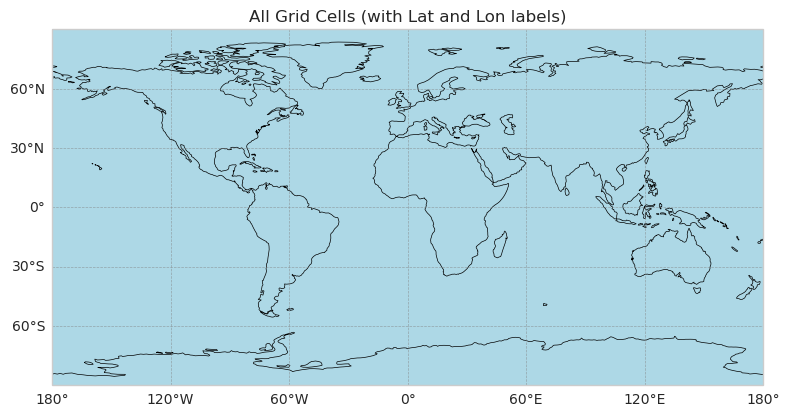

In [ ]:
# 先從 gg 取出 lon / lat，避免 VS Code 誤判
lon_all = gg[:, 0]
lat_all = gg[:, 1]

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# 經度轉換到 [-180, 180]
lon_plot = np.where(lon_all > 180, lon_all - 360, lon_all)
lat_plot = lat_all

fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.scatter(lon_plot, lat_plot, s=2, color="lightblue", transform=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.6, linestyle="--")
gl.top_labels = False
gl.right_labels = False

ax.set_title("All Grid Cells (with Lat and Lon labels)")
plt.tight_layout()
plt.show()


# 限制範圍抽樣 in USA

In [ ]:
# =========================
# 1. 定義美國本土範圍（可調整）
# =========================
# 緯度約 24°N ~ 50°N
lat_min, lat_max = 24.0, 50.0

# 經度如果是 -180~180 → 用 -125~-66
# 如果是 0~360（例如 MERRA-2）→ 對應 235~294
if np.max(gg[:, 0]) > 180:
    # 0-360 度系統
    lon_min, lon_max = 235.0, 294.0
else:
    # -180~180 度系統
    lon_min, lon_max = -125.0, -66.0

print(f"Using US bbox: lon [{lon_min}, {lon_max}], lat [{lat_min}, {lat_max}]")

# =========================
# 2. 建立遮罩，篩出美國格點
# =========================
lon_all = gg[:, 0]
lat_all = gg[:, 1]

mask_us = (
    (lat_all >= lat_min) & (lat_all <= lat_max) &
    (lon_all >= lon_min) & (lon_all <= lon_max)
)

idx_us = np.where(mask_us)[0]

if idx_us.size == 0:
    raise RuntimeError("US bbox filter selected 0 cells，請調整 lon/lat 範圍或確認經度座標系統。")

gg_us = gg[idx_us]           # (n_us, 2)
y_us = y_all[idx_us]         # (n_us, ntime)

print(f"US cells count: {gg_us.shape[0]}")
print(f"gg_us shape: {gg_us.shape}")
print(f"y_us shape: {y_us.shape}")

# =========================
# 3. 從美國格點中做抽樣
# =========================
# 指定抽樣 cell 數量
sample_size = 50  # 依你的記憶體/需求調整

if sample_size > gg_us.shape[0]:
    raise ValueError(f"sample_size={sample_size} > US cells={gg_us.shape[0]}")

rng = np.random.default_rng(seed=42)  # 固定 seed 方便重現
sample_idx = rng.choice(gg_us.shape[0], size=sample_size, replace=False)

gg_sample = gg_us[sample_idx]       # (sample_size, 2)
y_sample = y_us[sample_idx]         # (sample_size, ntime)

print(f"Sampled gg_sample shape: {gg_sample.shape}")
print(f"Sampled y_sample shape: {y_sample.shape}")

# 如果你比較想用「比例」抽樣，可以改成：
# frac = 0.1  # 抽 10%
# sample_size = int(np.floor(gg_us.shape[0] * frac))
# sample_idx = rng.choice(gg_us.shape[0], size=sample_size, replace=False)

Using US bbox: lon [-125.0, -66.0], lat [24.0, 50.0]
US cells count: 5035
gg_us shape: (5035, 2)
y_us shape: (5035, 548)
Sampled gg_sample shape: (50, 2)
Sampled y_sample shape: (50, 548)


## Seasonal ARIMA & DLinear

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import DLinearModel, ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =========================
# 1. 限制在美國範圍
# =========================

lat_min, lat_max = 24.0, 50.0

if np.max(gg[:, 0]) > 180:
    lon_min, lon_max = 235.0, 294.0  # 對應 -125~-66
else:
    lon_min, lon_max = -125.0, -66.0

lon_all = gg[:, 0]
lat_all = gg[:, 1]

mask_us = (
    (lat_all >= lat_min) & (lat_all <= lat_max) &
    (lon_all >= lon_min) & (lon_all <= lon_max)
)

idx_us = np.where(mask_us)[0]
if idx_us.size == 0:
    raise RuntimeError("US bbox filter selected 0 cells，請調整範圍或檢查經度系統。")

gg_us = gg[idx_us]
y_us = y_all[idx_us]

print(f"US cells count: {gg_us.shape[0]}")
print(f"gg_us shape: {gg_us.shape}")
print(f"y_us shape: {y_us.shape}")

# =========================
# 2. 抽樣部分格點
# =========================

SAMPLE_SIZE = 50

if SAMPLE_SIZE > gg_us.shape[0]:
    raise ValueError(f"sample_size={SAMPLE_SIZE} > US cells={gg_us.shape[0]}")

rng = np.random.default_rng(seed=42)
sample_idx = rng.choice(gg_us.shape[0], size=SAMPLE_SIZE, replace=False)

gg_sample = gg_us[sample_idx]
y_sample = y_us[sample_idx].astype(np.float32)  # 保證 float32

print(f"Sampled gg_sample shape: {gg_sample.shape}")
print(f"Sampled y_sample shape: {y_sample.shape}")

# =========================
# 3. 建 target DataFrame（氣溫，未標準化）
# =========================

ts_df = pd.DataFrame(
    y_sample.T,
    index=time_index,
    columns=[f"cell_{i}" for i in range(SAMPLE_SIZE)]
).astype("float32")

T = len(ts_df)
print("Total time steps:", T)

# =========================
# 4. 建 month covariate（用 float32）
# =========================

month_values = time_index.month.astype("float32")
month_df = pd.DataFrame({"month": month_values}, index=time_index).astype("float32")
month_ts = TimeSeries.from_dataframe(month_df)
print("Month covariate series:", month_ts)

# =========================
# 5. 切成 train / val / test（60 / 20 / 20）
# =========================

train_frac, val_frac = 0.6, 0.2
cut_train = int(T * train_frac)
cut_val = int(T * (train_frac + val_frac))

idx = ts_df.index
split_1_time = idx[cut_train]   # train: [0, cut_train-1]
split_2_time = idx[cut_val]     # val: [cut_train, cut_val-1], test: [cut_val, end]

# 先建「未標準化」的 TimeSeries（之後畫圖可以用）
ts_all_raw = TimeSeries.from_dataframe(ts_df)

train_raw, tmp_raw = ts_all_raw.split_before(split_1_time)
val_raw, test_raw = tmp_raw.split_before(split_2_time)

print(f"Train len (raw): {len(train_raw)}, Val len: {len(val_raw)}, Test len: {len(test_raw)}")

# month covariate 同步切
month_train, tmp_month = month_ts.split_before(split_1_time)
month_val, month_test = tmp_month.split_before(split_2_time)

assert len(month_train) == len(train_raw)
assert len(month_val) == len(val_raw)
assert len(month_test) == len(test_raw)

# =========================
# 6. 用「train 區間」的統計量標準化氣溫
# =========================

train_df = ts_df.iloc[:cut_train]   # (T_train, C)
mean_vec = train_df.mean(axis=0)    # 每個 cell 一個 mean
std_vec = train_df.std(axis=0)      # 每個 cell 一個 std

ts_df_scaled = (ts_df - mean_vec) / std_vec
ts_all_scaled = TimeSeries.from_dataframe(ts_df_scaled)

train_ts, tmp_ts = ts_all_scaled.split_before(split_1_time)
val_ts, test_ts = tmp_ts.split_before(split_2_time)

assert len(train_ts) == len(train_raw) == cut_train
assert len(val_ts) == len(val_raw) == (cut_val - cut_train)
assert len(test_ts) == len(test_raw) == (T - cut_val)

T_train = len(train_ts)
T_val = len(val_ts)
T_test = len(test_ts)

print(f"[Scaled] Train={T_train}, Val={T_val}, Test={T_test}")

# 之後預測時，我們會先在「標準化空間」預測，再用 mean/std 把預測轉回原本單位(K)

def inverse_scale(pred_scaled: np.ndarray) -> np.ndarray:
    """
    pred_scaled: shape (T_horizon, C)
    回傳：反標準化後的預測，同樣 shape
    """
    return pred_scaled * std_vec.values + mean_vec.values

# =========================
# 7. DLinearModel（baseline，調整參數＋用標準化資料）
#    → val / test 分開預測，減少 long-horizon 爆炸
# =========================

# 看過去大約半年的歷史（假設一個月 ~12 點）
INPUT_CHUNK_LENGTH = 72     # 比較穩定的輸入長度
OUTPUT_CHUNK_LENGTH = 12    # 一次預測 12 步

# ---------- 7(a). VAL：用 train_ts 訓練，預測 val 區段 ----------

model_dlinear_val = DLinearModel(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    n_epochs=50,
    random_state=42,
    # 可以視情況加一點 weight decay，幫忙穩定參數（可先打開試試）
    # optimizer_kwargs={"lr": 1e-3, "weight_decay": 1e-4},
)

print("\n=== Training DLinear for VAL ===")
model_dlinear_val.fit(
    series=train_ts,
    past_covariates=month_train,
    future_covariates=month_train,
    verbose=True,
)

# 只預測 validation horizon（標準化空間）
pred_dl_val = model_dlinear_val.predict(
    n=T_val,
    past_covariates=month_ts,    # 給整條 month，Darts 會自己取需要的部分
    future_covariates=month_ts,
)

# 轉成 (T_val, C)
pred_dl_val_vals = pred_dl_val.values(copy=False)
pred_dl_val_vals = np.asarray(pred_dl_val_vals)
if pred_dl_val_vals.ndim == 3 and pred_dl_val_vals.shape[-1] == 1:
    pred_dl_val_vals = pred_dl_val_vals[..., 0]

# 反標準化，回到原溫度單位 (T_val, C)
pred_dl_val_raw = inverse_scale(pred_dl_val_vals)

# 對應的真實值（原單位）
vals_all = ts_df.to_numpy(dtype=np.float32)  # (T, C)
val_true_raw = vals_all[cut_train:cut_val, :]   # (T_val, C)
test_true_raw = vals_all[cut_val:, :]           # (T_test, C)

# VAL MSE/MAE
mse_dl_val = mean_squared_error(
    val_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_dl_val_raw.reshape(-1, SAMPLE_SIZE),
)
mae_dl_val = mean_absolute_error(
    val_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_dl_val_raw.reshape(-1, SAMPLE_SIZE),
)

print("DLinear VAL shape:", pred_dl_val_raw.shape)
print("DLinear VAL  MSE:", mse_dl_val, "MAE:", mae_dl_val)

# ---------- 7(b). TEST：用 train_ts + val_ts 重新訓練，預測 test 區段 ----------

# 把標準化後的 train + val 接起來
train_val_ts = train_ts.concatenate(val_ts)
month_train_val = month_train.concatenate(month_val)

model_dlinear_test = DLinearModel(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    n_epochs=50,
    random_state=42,
    # optimizer_kwargs={"lr": 1e-3, "weight_decay": 1e-4},
)

print("\n=== Training DLinear for TEST (train+val) ===")
model_dlinear_test.fit(
    series=train_val_ts,
    past_covariates=month_train_val,
    future_covariates=month_train_val,
    verbose=True,
)

# 只預測 test horizon（標準化空間）
pred_dl_test = model_dlinear_test.predict(
    n=T_test,
    past_covariates=month_ts,
    future_covariates=month_ts,
)

# 轉成 (T_test, C)
pred_dl_test_vals = pred_dl_test.values(copy=False)
pred_dl_test_vals = np.asarray(pred_dl_test_vals)
if pred_dl_test_vals.ndim == 3 and pred_dl_test_vals.shape[-1] == 1:
    pred_dl_test_vals = pred_dl_test_vals[..., 0]

# 反標準化，回到原單位
pred_dl_test_raw = inverse_scale(pred_dl_test_vals)   # (T_test, C)

# TEST MSE/MAE
mse_dl_test = mean_squared_error(
    test_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_dl_test_raw.reshape(-1, SAMPLE_SIZE),
)
mae_dl_test = mean_absolute_error(
    test_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_dl_test_raw.reshape(-1, SAMPLE_SIZE),
)

print("DLinear TEST shape:", pred_dl_test_raw.shape)
print("DLinear TEST MSE:", mse_dl_test, "MAE:", mae_dl_test)

# =========================
# 8. 50 個獨立 Seasonal ARIMA (SARIMA) baseline（也用標準化資料）
# =========================

# 非季節 ARIMA 階數
P_AR, D_AR, Q_AR = 1, 0, 0
# 季節部分 (P, D, Q, s)，這裡假設一年 12 期的季節性
P_SEAS, D_SEAS, Q_SEAS, S_SEAS = 1, 0, 0, 12

# VAL + TEST 的總步數（給 SARIMA 用）
n_total = T_val + T_test

# 存放所有格點的「val+test」預測（標準化空間）：形狀 (T_val+T_test, SAMPLE_SIZE)
pred_sar_all_scaled = np.zeros((n_total, SAMPLE_SIZE), dtype=np.float32)

for i, col in enumerate(ts_df.columns):
    # 取出單一格點的 univariate series（標準化後）
    series_train_i = train_ts.univariate_component(col)

    # 建立 SARIMA 模型（使用 seasonal_order）
    model_sarima_i = ARIMA(
        p=P_AR,
        d=D_AR,
        q=Q_AR,
        seasonal_order=(P_SEAS, D_SEAS, Q_SEAS, S_SEAS),
    )

    # 擬合（用 train 區間的 month covariate）
    model_sarima_i.fit(
        series=series_train_i,
        future_covariates=month_train,
    )

    # 預測 val+test 全部 horizon（標準化空間）
    pred_i = model_sarima_i.predict(
        n=n_total,
        future_covariates=month_ts,  # 提供整條 month
    )

    pred_i_vals = pred_i.values().reshape(-1)
    pred_sar_all_scaled[:, i] = pred_i_vals

print("SARIMA pred (scaled) shape:", pred_sar_all_scaled.shape)

# 反標準化
pred_sar_all_raw = inverse_scale(pred_sar_all_scaled)  # (T_val+T_test, C)

# 拆成 val / test
pred_sar_val_raw = pred_sar_all_raw[:T_val, :]
pred_sar_test_raw = pred_sar_all_raw[T_val:, :]

# MSE/MAE（val / test）
mse_sar_val = mean_squared_error(
    val_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_sar_val_raw.reshape(-1, SAMPLE_SIZE)
)
mae_sar_val = mean_absolute_error(
    val_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_sar_val_raw.reshape(-1, SAMPLE_SIZE)
)

mse_sar_test = mean_squared_error(
    test_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_sar_test_raw.reshape(-1, SAMPLE_SIZE)
)
mae_sar_test = mean_absolute_error(
    test_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_sar_test_raw.reshape(-1, SAMPLE_SIZE)
)

print("SARIMA VAL  MSE:", mse_sar_val,  "MAE:", mae_sar_val)
print("SARIMA TEST MSE:", mse_sar_test, "MAE:", mae_sar_test)

# =========================
# 9. 輸出 MSE / MAE table（VAL / TEST）
# =========================

metrics_table = pd.DataFrame({
    "Model": ["DLinear", "DLinear", "SARIMA (per cell)", "SARIMA (per cell)"],
    "Split": ["VAL",    "TEST",   "VAL",               "TEST"],
    "MSE":   [mse_dl_val, mse_dl_test, mse_sar_val, mse_sar_test],
    "MAE":   [mae_dl_val, mae_dl_test, mae_sar_val, mae_sar_test],
})

print("\nMSE / MAE comparison (train/val/test with standardized temps):")
print(metrics_table.to_string(index=False))


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | decomposition   | _SeriesDecomp    | 0      | train
6 | linear_seasonal | Linear           | 2.2 M  | train
7 | linear_trend    | Linear           | 2.2 M  | train
8 | linear_fut_cov  | Linear           | 100    | train
-------------------------------------------------------------
4.5 M     Trainable params
0         Non-trainable params
4.5 M     Total params
17.976    Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
/home/jundi

US cells count: 5035
gg_us shape: (5035, 2)
y_us shape: (5035, 548)
Sampled gg_sample shape: (50, 2)
Sampled y_sample shape: (50, 548)
Total time steps: 548
Month covariate series: <TimeSeries (DataArray) (time: 548, component: 1, sample: 1)> Size: 2kB
array([[[ 1.]],

       [[ 2.]],

       [[ 3.]],

       [[ 4.]],

       [[ 5.]],

       [[ 6.]],

       [[ 7.]],

       [[ 8.]],

       [[ 9.]],

       [[10.]],

...

       [[11.]],

       [[12.]],

       [[ 1.]],

       [[ 2.]],

       [[ 3.]],

       [[ 4.]],

       [[ 5.]],

       [[ 6.]],

       [[ 7.]],

       [[ 8.]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1980-01-01T00:30:00 ... 2025-08-01T0...
  * component  (component) object 8B 'month'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None
Train len (raw): 328, Val len: 110, Test len: 110
[Scaled] Train=328, Val=110, Test=110

=== Training DLinear 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 8/8 [00:00<00:00, 67.22it/s, train_loss=0.0229]

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


...

Epoch 49: 100%|██████████| 12/12 [00:00<00:00, 71.20it/s, train_loss=0.0309]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 12/12 [00:00<00:00, 70.53it/s, train_loss=0.0309]


`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 123.15it/s]
DLinear TEST shape: (110, 50)
DLinear TEST MSE: 26.459997177124023 MAE: 3.4789130687713623
SARIMA pred (scaled) shape: (220, 50)
SARIMA VAL  MSE: 10.2144193649292 MAE: 2.4890036582946777
SARIMA TEST MSE: 27.926443099975586 MAE: 4.2964677810668945

MSE / MAE comparison (train/val/test with standardized temps):
            Model Split       MSE      MAE
          DLinear   VAL  7.981932 2.111541
          DLinear  TEST 26.459997 3.478913
SARIMA (per cell)   VAL 10.214419 2.489004
SARIMA (per cell)  TEST 27.926443 4.296468


| Model              | Split | MSE      | MAE      |
|--------------------|:-----:|---------:|---------:|
| **DLinear**        |  VAL  | **7.98** | **2.11** |
| **DLinear**        | TEST  | **26.46**| **3.48** |
| SARIMA|  VAL  | 10.21    | 2.49     |
| SARIMA| TEST  | 27.93    | 4.30     |
|  VAR  |  VAL  | 17.756997 | 3.146399 |
|  VAR  | TEST  | 30.403140 | 4.352151 |

## VARIMA & DLinear

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import DLinearModel
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.api import VAR

# =========================
# 1. 限制在美國範圍
# =========================

lat_min, lat_max = 24.0, 50.0

if np.max(gg[:, 0]) > 180:
    lon_min, lon_max = 235.0, 294.0  # 對應 -125~-66
else:
    lon_min, lon_max = -125.0, -66.0

lon_all = gg[:, 0]
lat_all = gg[:, 1]

mask_us = (
    (lat_all >= lat_min) & (lat_all <= lat_max) &
    (lon_all >= lon_min) & (lon_all <= lon_max)
)

idx_us = np.where(mask_us)[0]
if idx_us.size == 0:
    raise RuntimeError("US bbox filter selected 0 cells，請調整範圍或檢查經度系統。")

gg_us = gg[idx_us]
y_us = y_all[idx_us]

print(f"US cells count: {gg_us.shape[0]}")
print(f"gg_us shape: {gg_us.shape}")
print(f"y_us shape: {y_us.shape}")

# =========================
# 2. 抽樣部分格點
# =========================

SAMPLE_SIZE = 50

if SAMPLE_SIZE > gg_us.shape[0]:
    raise ValueError(f"sample_size={SAMPLE_SIZE} > US cells={gg_us.shape[0]}")

rng = np.random.default_rng(seed=42)
sample_idx = rng.choice(gg_us.shape[0], size=SAMPLE_SIZE, replace=False)

gg_sample = gg_us[sample_idx]
y_sample = y_us[sample_idx].astype(np.float32)  # 保證 float32

print(f"Sampled gg_sample shape: {gg_sample.shape}")
print(f"Sampled y_sample shape: {y_sample.shape}")

# =========================
# 3. 建 target DataFrame（氣溫，未標準化）
# =========================

ts_df = pd.DataFrame(
    y_sample.T,
    index=time_index,
    columns=[f"cell_{i}" for i in range(SAMPLE_SIZE)]
).astype("float32")

T = len(ts_df)
print("Total time steps:", T)

# =========================
# 4. 建 month covariate（用 float32）
# =========================

month_values = time_index.month.astype("float32")
month_df = pd.DataFrame({"month": month_values}, index=time_index).astype("float32")
month_ts = TimeSeries.from_dataframe(month_df)
print("Month covariate series:", month_ts)

# =========================
# 5. 切成 train / val / test（60 / 20 / 20）
# =========================

train_frac, val_frac = 0.6, 0.2
cut_train = int(T * train_frac)
cut_val = int(T * (train_frac + val_frac))

idx = ts_df.index
split_1_time = idx[cut_train]   # train: [0, cut_train-1]
split_2_time = idx[cut_val]     # val: [cut_train, cut_val-1], test: [cut_val, end]

# 先建「未標準化」的 TimeSeries（之後畫圖可以用）
ts_all_raw = TimeSeries.from_dataframe(ts_df)

train_raw, tmp_raw = ts_all_raw.split_before(split_1_time)
val_raw, test_raw = tmp_raw.split_before(split_2_time)

print(f"Train len (raw): {len(train_raw)}, Val len: {len(val_raw)}, Test len: {len(test_raw)}")

# month covariate 同步切
month_train, tmp_month = month_ts.split_before(split_1_time)
month_val, month_test = tmp_month.split_before(split_2_time)

assert len(month_train) == len(train_raw)
assert len(month_val) == len(val_raw)
assert len(month_test) == len(test_raw)

# =========================
# 6. 用「train 區間」的統計量標準化氣溫
# =========================

train_df = ts_df.iloc[:cut_train]   # (T_train, C)
mean_vec = train_df.mean(axis=0)    # 每個 cell 一個 mean
std_vec = train_df.std(axis=0)      # 每個 cell 一個 std

ts_df_scaled = (ts_df - mean_vec) / std_vec
ts_all_scaled = TimeSeries.from_dataframe(ts_df_scaled)

train_ts, tmp_ts = ts_all_scaled.split_before(split_1_time)
val_ts, test_ts = tmp_ts.split_before(split_2_time)

assert len(train_ts) == len(train_raw) == cut_train
assert len(val_ts) == len(val_raw) == (cut_val - cut_train)
assert len(test_ts) == len(test_raw) == (T - cut_val)

T_train = len(train_ts)
T_val = len(val_ts)
T_test = len(test_ts)

print(f"[Scaled] Train={T_train}, Val={T_val}, Test={T_test}")

# 之後預測時，我們會先在「標準化空間」預測，再用 mean/std 把預測轉回原本單位(K)

def inverse_scale(pred_scaled: np.ndarray) -> np.ndarray:
    """
    pred_scaled: shape (T_horizon, C)
    回傳：反標準化後的預測，同樣 shape
    """
    return pred_scaled * std_vec.values + mean_vec.values

# =========================
# 7. DLinearModel（baseline，調整參數＋用標準化資料）
#    → val / test 分開預測，減少 long-horizon 爆炸
# =========================

# 看過去大約半年的歷史（假設一個月 ~12 點）
INPUT_CHUNK_LENGTH = 72     # 比較穩定的輸入長度
OUTPUT_CHUNK_LENGTH = 12    # 一次預測 12 步

# ---------- 7(a). VAL：用 train_ts 訓練，預測 val 區段 ----------

model_dlinear_val = DLinearModel(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    n_epochs=50,
    random_state=42,
)

print("\n=== Training DLinear for VAL ===")
model_dlinear_val.fit(
    series=train_ts,
    past_covariates=month_train,
    future_covariates=month_train,
    verbose=True,
)

# 只預測 validation horizon（標準化空間）
pred_dl_val = model_dlinear_val.predict(
    n=T_val,
    past_covariates=month_ts,    # 給整條 month，Darts 會自己取需要的部分
    future_covariates=month_ts,
)

# 轉成 (T_val, C)
pred_dl_val_vals = np.asarray(pred_dl_val.values(copy=False))
if pred_dl_val_vals.ndim == 3 and pred_dl_val_vals.shape[-1] == 1:
    pred_dl_val_vals = pred_dl_val_vals[..., 0]

# 反標準化，回到原溫度單位 (T_val, C)
pred_dl_val_raw = inverse_scale(pred_dl_val_vals)

# 對應的真實值（原單位）
vals_all = ts_df.to_numpy(dtype=np.float32)  # (T, C)
val_true_raw = vals_all[cut_train:cut_val, :]   # (T_val, C)
test_true_raw = vals_all[cut_val:, :]           # (T_test, C)

# VAL MSE/MAE
mse_dl_val = mean_squared_error(
    val_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_dl_val_raw.reshape(-1, SAMPLE_SIZE),
)
mae_dl_val = mean_absolute_error(
    val_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_dl_val_raw.reshape(-1, SAMPLE_SIZE),
)

print("DLinear VAL shape:", pred_dl_val_raw.shape)
print("DLinear VAL  MSE:", mse_dl_val, "MAE:", mae_dl_val)

# ---------- 7(b). TEST：用 train_ts + val_ts 重新訓練，預測 test 區段 ----------

# 把標準化後的 train + val 接起來
train_val_ts = train_ts.concatenate(val_ts)
month_train_val = month_train.concatenate(month_val)

model_dlinear_test = DLinearModel(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    n_epochs=50,
    random_state=42,
)

print("\n=== Training DLinear for TEST (train+val) ===")
model_dlinear_test.fit(
    series=train_val_ts,
    past_covariates=month_train_val,
    future_covariates=month_train_val,
    verbose=True,
)

# 只預測 test horizon（標準化空間）
pred_dl_test = model_dlinear_test.predict(
    n=T_test,
    past_covariates=month_ts,
    future_covariates=month_ts,
)

# 轉成 (T_test, C)
pred_dl_test_vals = np.asarray(pred_dl_test.values(copy=False))
if pred_dl_test_vals.ndim == 3 and pred_dl_test_vals.shape[-1] == 1:
    pred_dl_test_vals = pred_dl_test_vals[..., 0]

# 反標準化，回到原單位
pred_dl_test_raw = inverse_scale(pred_dl_test_vals)   # (T_test, C)

# TEST MSE/MAE
mse_dl_test = mean_squared_error(
    test_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_dl_test_raw.reshape(-1, SAMPLE_SIZE),
)
mae_dl_test = mean_absolute_error(
    test_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_dl_test_raw.reshape(-1, SAMPLE_SIZE),
)

print("DLinear TEST shape:", pred_dl_test_raw.shape)
print("DLinear TEST MSE:", mse_dl_test, "MAE:", mae_dl_test)

# =========================
# 8. VAR(1) baseline（一次 50 個地點，多變量 VAR）
# =========================

P_VAR = 1  # VAR(1)

# ---------- 8(a). VAL：用 train 區間訓練 VAR(1)，預測 val ----------

train_scaled_df = ts_df_scaled.iloc[:cut_train]     # (T_train, C)
var_model_val = VAR(train_scaled_df)
var_res_val = var_model_val.fit(P_VAR)              # 固定用 lag=1

k_ar_val = var_res_val.k_ar
history_val = train_scaled_df.values[-k_ar_val:, :]  # 取最後 k_ar 期當起始
forecast_val_scaled = var_res_val.forecast(y=history_val, steps=T_val)  # (T_val, C)

pred_var_val_raw = inverse_scale(forecast_val_scaled)

mse_var_val = mean_squared_error(
    val_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_var_val_raw.reshape(-1, SAMPLE_SIZE),
)
mae_var_val = mean_absolute_error(
    val_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_var_val_raw.reshape(-1, SAMPLE_SIZE),
)

print("VAR(1) VAL shape:", pred_var_val_raw.shape)
print("VAR(1) VAL  MSE:", mse_var_val, "MAE:", mae_var_val)

# ---------- 8(b). TEST：用 train+val 訓練 VAR(1)，預測 test ----------

train_val_scaled_df = ts_df_scaled.iloc[:cut_val]   # (T_train+T_val, C)
var_model_test = VAR(train_val_scaled_df)
var_res_test = var_model_test.fit(P_VAR)

k_ar_test = var_res_test.k_ar
history_test = train_val_scaled_df.values[-k_ar_test:, :]
forecast_test_scaled = var_res_test.forecast(y=history_test, steps=T_test)  # (T_test, C)

pred_var_test_raw = inverse_scale(forecast_test_scaled)

mse_var_test = mean_squared_error(
    test_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_var_test_raw.reshape(-1, SAMPLE_SIZE),
)
mae_var_test = mean_absolute_error(
    test_true_raw.reshape(-1, SAMPLE_SIZE),
    pred_var_test_raw.reshape(-1, SAMPLE_SIZE),
)

print("VAR(1) TEST shape:", pred_var_test_raw.shape)
print("VAR(1) TEST MSE:", mse_var_test, "MAE:", mae_var_test)

# =========================
# 9. 輸出 MSE / MAE table（VAL / TEST）
# =========================

metrics_table = pd.DataFrame({
    "Model": ["DLinear", "DLinear", "VAR(1)", "VAR(1)"],
    "Split": ["VAL",    "TEST",   "VAL",   "TEST"],
    "MSE":   [mse_dl_val, mse_dl_test, mse_var_val, mse_var_test],
    "MAE":   [mae_dl_val, mae_dl_test, mae_var_val, mae_var_test],
})

print("\nMSE / MAE comparison (train/val/test with standardized temps):")
print(metrics_table.to_string(index=False))


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | decomposition   | _SeriesDecomp    | 0      | train
6 | linear_seasonal | Linear           | 2.2 M  | train
7 | linear_trend    | Linear           | 2.2 M  | train
8 | linear_fut_cov  | Linear           | 100    | train
-------------------------------------------------------------
4.5 M     Trainable params
0         Non-trainable params
4.5 M     Total params
17.976    Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
/home/jundi

US cells count: 5035
gg_us shape: (5035, 2)
y_us shape: (5035, 548)
Sampled gg_sample shape: (50, 2)
Sampled y_sample shape: (50, 548)
Total time steps: 548
Month covariate series: <TimeSeries (DataArray) (time: 548, component: 1, sample: 1)> Size: 2kB
array([[[ 1.]],

       [[ 2.]],

       [[ 3.]],

       [[ 4.]],

       [[ 5.]],

       [[ 6.]],

       [[ 7.]],

       [[ 8.]],

       [[ 9.]],

       [[10.]],

...

       [[11.]],

       [[12.]],

       [[ 1.]],

       [[ 2.]],

       [[ 3.]],

       [[ 4.]],

       [[ 5.]],

       [[ 6.]],

       [[ 7.]],

       [[ 8.]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1980-01-01T00:30:00 ... 2025-08-01T0...
  * component  (component) object 8B 'month'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None
Train len (raw): 328, Val len: 110, Test len: 110
[Scaled] Train=328, Val=110, Test=110

=== Training DLinear 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 8/8 [00:00<00:00, 60.84it/s, train_loss=0.0229]

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


...

Epoch 49: 100%|██████████| 12/12 [00:00<00:00, 68.49it/s, train_loss=0.0309]

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 52.58it/s]
DLinear TEST shape: (110, 50)
DLinear TEST MSE: 26.459997177124023 MAE: 3.4789130687713623
VAR(1) VAL shape: (110, 50)
VAR(1) VAL  MSE: 17.756997302318066 MAE: 3.1463994134801077
VAR(1) TEST shape: (110, 50)
VAR(1) TEST MSE: 30.40314027767242 MAE: 4.352150702746176

MSE / MAE comparison (train/val/test with standardized temps):
  Model Split       MSE      MAE
DLinear   VAL  7.981932 2.111541
DLinear  TEST 26.459997 3.478913
 VAR(1)   VAL 17.756997 3.146399
 VAR(1)  TEST 30.403140 4.352151


/home/jundian/miniconda3/envs/geospatial-neural-adapter/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/jundian/miniconda3/envs/geospatial-neural-adapter/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 從美國抽的50個站點 畫圖

### 各站位置

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 建立輸出資料夾
out_dir = "photo"
os.makedirs(out_dir, exist_ok=True)

# 從抽樣結果取座標
lon_sample = gg_sample[:, 0]
lat_sample = gg_sample[:, 1]

# 如果原始是 0~360，就跟前面一樣用同一套系統
lon_plot = lon_sample

fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# 視窗範圍使用你定義的美國 bbox
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# 底圖
ax.coastlines(resolution="50m")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)

# 抽樣點散佈
ax.scatter(lon_plot, lat_sample,
           s=20,
           transform=ccrs.PlateCarree())

# 加上站點標號（用抽樣順序編號：0,1,2,...）
for i, (x, y) in enumerate(zip(lon_plot, lat_sample)):
    ax.text(
        x,
        y,
        str(i),
        transform=ccrs.PlateCarree(),
        fontsize=6,
        ha="left",
        va="bottom",
    )

ax.set_title("Sampled 50 grid points over US region (indexed)")
plt.tight_layout()


# 存檔到 photo 資料夾
out_path = os.path.join(out_dir, "sampled_50_grid_points_US.png")
plt.savefig(out_path, dpi=150)
plt.close()

print(f"Figure saved to: {out_path}")


Figure saved to: photo/sampled_50_grid_points_US.png


### SARIMA 殘差 ACF / PACF 圖

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# =========================
# 基本設定
# =========================
output_dir = "photo/SARIMA_resid_acf_pacf_50stations"
os.makedirs(output_dir, exist_ok=True)

# 這裡改成用 ts_df，而不是 ts_all
# ts_df: 形狀 (T, C)，index = 時間, columns = 各測站/格點名稱
vals = ts_df.to_numpy(dtype=float)
vals = np.asarray(vals)

T, C = vals.shape
idx = ts_df.index          # 時間索引
names = ts_df.columns      # 各站名稱（或 cell_xxx）

print(f"T={T}, C={C}, saving SARIMA residual ACF/PACF plots to: {output_dir}")

# SARIMA 階數設定（依你的資料頻率調整）
ORDER = (1, 0, 0)
SEASONAL_ORDER = (1, 0, 0, 12)   # 例如一年 12 期，如果是小時資料可以改成 24

MAX_LAG = 40     # ACF/PACF 顯示到的 lag，可自行調

for j in range(C):
    name = str(names[j])
    series = pd.Series(vals[:, j], index=idx)

    # 去掉 NaN（如果原始 series 有缺值，SARIMA 會直接報錯）
    series = series.dropna()
    if len(series) <= MAX_LAG + 10:
        # 太短就跳過，避免 statsmodels 報錯
        print(f"Skip {name}: series too short after dropna (len={len(series)})")
        continue

    # 1) SARIMA 擬合
    try:
        model = SARIMAX(
            series,
            order=ORDER,
            seasonal_order=SEASONAL_ORDER,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        result = model.fit(disp=False)
    except Exception as e:
        print(f"SARIMA fit failed for {name}: {e}")
        continue

    # 2) 取得殘差（觀測值 - 一步預測）
    resid = result.resid.dropna()
    if len(resid) <= MAX_LAG + 5:
        print(f"Skip {name}: residuals too short (len={len(resid)})")
        continue

    # 3) 畫 ACF / PACF（同一張圖，上 ACF 下 PACF）
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

    plot_acf(resid, lags=MAX_LAG, ax=ax1)
    ax1.set_title(f"SARIMA Residual ACF - {name}")

    plot_pacf(resid, lags=MAX_LAG, ax=ax2, method="ywm")
    ax2.set_title(f"SARIMA Residual PACF - {name}")
    ax2.set_xlabel("Lag")

    plt.tight_layout()

    # 檔名處理
    safe_name = name.replace(" ", "_").replace("/", "_")
    save_path = os.path.join(output_dir, f"{safe_name}_sarima_resid_acf_pacf.png")

    plt.savefig(save_path, dpi=150)
    plt.close(fig)

print("Done: all SARIMA residual ACF/PACF plots saved.")


T=548, C=50, saving SARIMA residual ACF/PACF plots to: photo/SARIMA_resid_acf_pacf_50stations


/home/jundian/miniconda3/envs/geospatial-neural-adapter/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/jundian/miniconda3/envs/geospatial-neural-adapter/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/jundian/miniconda3/envs/geospatial-neural-adapter/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/jundian/miniconda3/envs/geospatial-neural-adapter/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/ju

Done: all SARIMA residual ACF/PACF plots saved.


### DLinear 殘差 ACF/PACF 圖

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# =========================
# DLinear 殘差 ACF / PACF
# =========================

output_dir = "photo/DLinear_resid_acf_pacf_50stations"
os.makedirs(output_dir, exist_ok=True)

# val / test 殘差（原單位）
resid_val = val_true_raw - pred_dl_val_raw      # shape (T_val,  SAMPLE_SIZE)
resid_test = test_true_raw - pred_dl_test_raw   # shape (T_test, SAMPLE_SIZE)

# 接成一條（val 接 test）
resid_all = np.vstack([resid_val, resid_test])  # shape (T_val+T_test, SAMPLE_SIZE)

# 對應的時間 index（val + test）
idx_val = ts_df.index[cut_train:cut_val]
idx_test = ts_df.index[cut_val:]
idx_all = idx_val.append(idx_test)

T_resid, C = resid_all.shape
names = ts_df.columns

print(f"DLinear residuals: T={T_resid}, C={C}, saving to: {output_dir}")

MAX_LAG = 40   # ACF / PACF 最大 lag

for j in range(C):
    name = str(names[j])

    series_resid = pd.Series(resid_all[:, j], index=idx_all)
    series_resid = series_resid.dropna()

    if len(series_resid) <= MAX_LAG + 5:
        print(f"Skip {name}: residual series too short (len={len(series_resid)})")
        continue

    # 一張圖：上面 ACF，下面 PACF
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

    plot_acf(series_resid, lags=MAX_LAG, ax=ax1)
    ax1.set_title(f"DLinear Residual ACF - {name}")

    plot_pacf(series_resid, lags=MAX_LAG, ax=ax2, method="ywm")
    ax2.set_title(f"DLinear Residual PACF - {name}")
    ax2.set_xlabel("Lag")

    plt.tight_layout()

    # 檔名處理
    safe_name = name.replace(" ", "_").replace("/", "_")
    save_path = os.path.join(output_dir, f"{safe_name}_dlinear_resid_acf_pacf.png")

    plt.savefig(save_path, dpi=150)
    plt.close(fig)

print("Done: all DLinear residual ACF/PACF plots saved.")


DLinear residuals: T=220, C=50, saving to: photo/DLinear_resid_acf_pacf_50stations
Done: all DLinear residual ACF/PACF plots saved.


### seasonal_decompose

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# ------------------------
# 基本設定
# ------------------------
output_dir = "photo/seasonal_50stations"
os.makedirs(output_dir, exist_ok=True)

vals = ts_all.values(copy=False)
vals = np.asarray(vals)

# 若為 (T, C, 1) → (T, C)
if vals.ndim == 3 and vals.shape[-1] == 1:
    vals = vals[..., 0]

T, C = vals.shape
idx = ts_all.time_index
names = ts_all.components  # e.g. 'cell_0', 'cell_1', ...

print(f"T={T}, C={C}, saving to: {output_dir}")

period = 12  # 月資料 → 一年 12 期

for j in range(C):
    name = str(names[j])
    series = pd.Series(vals[:, j], index=idx)

    # seasonal decomposition
    result = seasonal_decompose(
        series,
        model="additive",
        period=period,
        extrapolate_trend="freq"
    )

    fig = result.plot()
    fig.set_size_inches(10, 6)
    fig.suptitle(f"Seasonal-Trend Decomposition - {name}", y=0.98)

    # 檔名安全一點：把空白和奇怪字元換掉
    safe_name = name.replace(" ", "_").replace("/", "_")
    save_path = os.path.join(output_dir, f"{safe_name}.png")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close(fig)

print("Done: all station decomposition plots saved.")


### 各站 raw data&mean

T=548, C=50


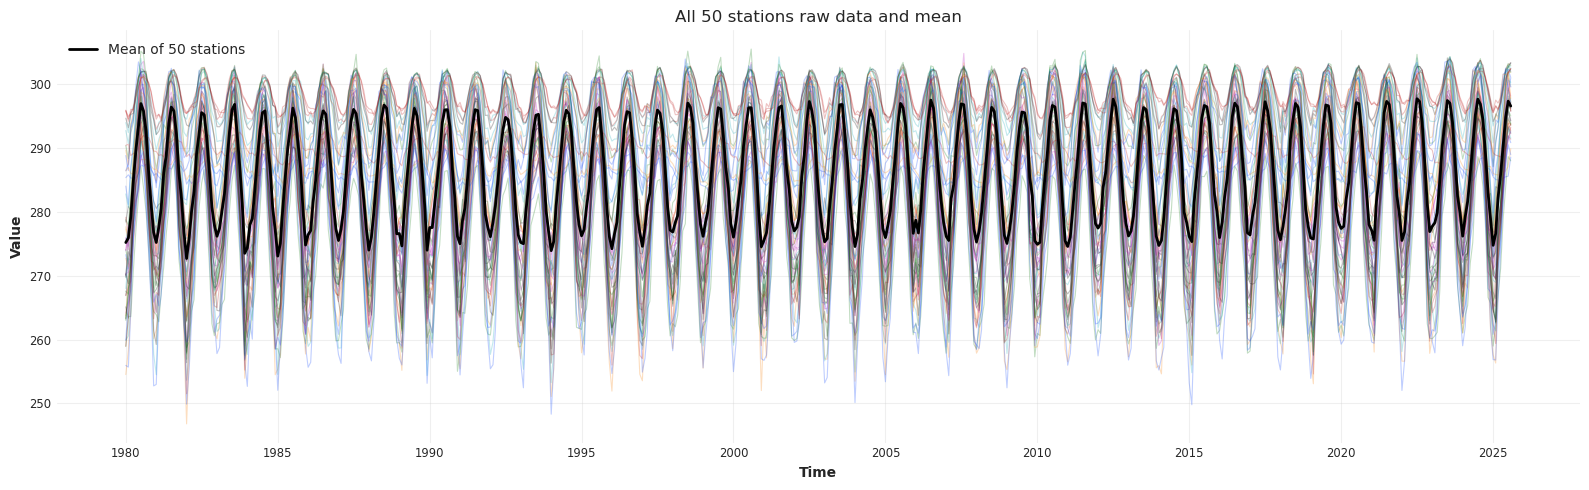

Figure saved to: photo/all_50_stations_raw_and_mean.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 建立輸出資料夾
out_dir = "photo"
os.makedirs(out_dir, exist_ok=True)

# ============ 轉成 (T, C) ============
vals = ts_all.values(copy=False)
vals = np.asarray(vals)

if vals.ndim == 3 and vals.shape[-1] == 1:
    vals = vals[..., 0]

T, C = vals.shape
idx = ts_all.time_index
names = ts_all.components

print(f"T={T}, C={C}")

# ============ DLinear 預測的平均 ============
# pred_dlinear: (T_val, C, 1) 或 (T_val, C)
pred_vals = pred_dlinear.values(copy=False)
pred_vals = np.asarray(pred_vals)
if pred_vals.ndim == 3 and pred_vals.shape[-1] == 1:
    pred_vals = pred_vals[..., 0]   # 變成 (T_val, C)

val_idx = val_ts.time_index                # 驗證區間的時間軸
split_time = val_idx[0]                    # 預測開始時間
mean_pred = pred_vals.mean(axis=1)         # (T_val, )

# ============ 作圖 ============
plt.figure(figsize=(16, 5))

# 1) 50 條原始序列（淡色）
for j in range(C):
    plt.plot(idx, vals[:, j], linewidth=0.8, alpha=0.25)

# 2) 全期真實平均（黑色實線）
mean_vals = vals.mean(axis=1)
plt.plot(idx, mean_vals, color="black", linewidth=2.0, label="Mean of 50 stations")

plt.title("All 50 stations raw data and mean")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.legend(loc="upper left")

plt.tight_layout()

# 存檔到 photo 資料夾
out_path = os.path.join(out_dir, "all_50_stations_raw_and_mean.png")
plt.savefig(out_path, dpi=150)
plt.show()
plt.close()

print(f"Figure saved to: {out_path}")


### 各站 raw data&mean&預測 (from 2015)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

output_dir = "photo/station_raw_mean_forecast_from2015"
os.makedirs(output_dir, exist_ok=True)

# ---------- 1. raw data (T, C) ----------
vals = ts_all.values(copy=False)
vals = np.asarray(vals)
if vals.ndim == 3 and vals.shape[-1] == 1:
    vals = vals[..., 0]

T, C = vals.shape
idx = ts_all.time_index
names = ts_all.components
print(f"T={T}, C={C}")

# ---------- 2. DLinear / SARIMA 預測 (T_val, C) ----------
pred_vals_dl = pred_dlinear.values(copy=False)
pred_vals_dl = np.asarray(pred_vals_dl)
if pred_vals_dl.ndim == 3 and pred_vals_dl.shape[-1] == 1:
    pred_vals_dl = pred_vals_dl[..., 0]

pred_vals_sar = pred_sarima_vals   # 已經是 (T_val, C)
val_idx = val_ts.time_index
split_time = val_idx[0]

# ---------- 3. 只取 2015 之後 ----------
start_plot = pd.Timestamp("2015-01-01")

# 原始資料：2015 之後
mask_2015_all = idx >= start_plot
idx_2015_all = idx[mask_2015_all]
vals_2015_all = vals[mask_2015_all]

# 預測資料：驗證區間中時間 >= 2015
mask_val_2015 = val_idx >= start_plot
val_idx_2015 = val_idx[mask_val_2015]
pred_vals_dl_2015 = pred_vals_dl[mask_val_2015]
pred_vals_sar_2015 = pred_vals_sar[mask_val_2015]

# 灰底開始 / 結束時間
shade_start = max(split_time, idx_2015_all[0])
shade_end = idx_2015_all[-1]

# ---------- 4. 逐站畫圖並存檔 ----------
for j in range(C):
    # 該站 2015 之後的 raw
    y_j_2015 = vals_2015_all[:, j]
    mean_j_2015 = y_j_2015.mean()

    # 該站 2015 之後的預測
    yhat_dl_j_2015 = pred_vals_dl_2015[:, j]
    yhat_sar_j_2015 = pred_vals_sar_2015[:, j]

    plt.figure(figsize=(10, 4))

    # 1) raw data (2015~)
    plt.plot(idx_2015_all, y_j_2015,
             color="black", linewidth=1.5, label="Raw data (from 2015)")

    # 2) 2015 之後的時間平均
    plt.axhline(mean_j_2015,
                color="grey", linestyle="--", linewidth=1.2,
                label="Mean (from 2015)")

    # 3) 預測區間灰底
    plt.axvspan(shade_start, shade_end,
                color="grey", alpha=0.15, label="Forecast horizon")

    # 4) DLinear 預測（藍虛線，2015~）
    plt.plot(val_idx_2015, yhat_dl_j_2015,
             color="blue", linestyle="--", linewidth=1.5,
             label="DLinear forecast")

    # 5) SARIMA 預測（紅虛線，2015~）
    plt.plot(val_idx_2015, yhat_sar_j_2015,
             color="red", linestyle="--", linewidth=1.5,
             label="SARIMA forecast")

    # 6) 預測起點垂直線（如果在 2015 之後）
    if split_time >= idx_2015_all[0]:
        plt.axvline(split_time, color="grey", linestyle=":", linewidth=1)

    plt.title(f"{names[j]}: Raw data, mean and forecasts (from 2015)")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.grid(alpha=0.3)

    # legend 放在圖外上方
    plt.legend(
        loc="upper left",
        bbox_to_anchor=(0.01, 1.02),
        ncol=4,
        framealpha=0.9,
        fontsize=9
    )

    plt.tight_layout()

    fname = f"station_{j:02d}_{names[j]}_from2015.png"
    plt.savefig(os.path.join(output_dir, fname),
                dpi=150, bbox_inches="tight")
    plt.close()

print(f"已將 {C} 張 2015 之後的圖存到資料夾：{output_dir}")


T=548, C=50
已將 50 張 2015 之後的圖存到資料夾：photo/station_raw_mean_forecast_from2015


### raw data&mean&預測平均 (from 2015)

T=548, C=50


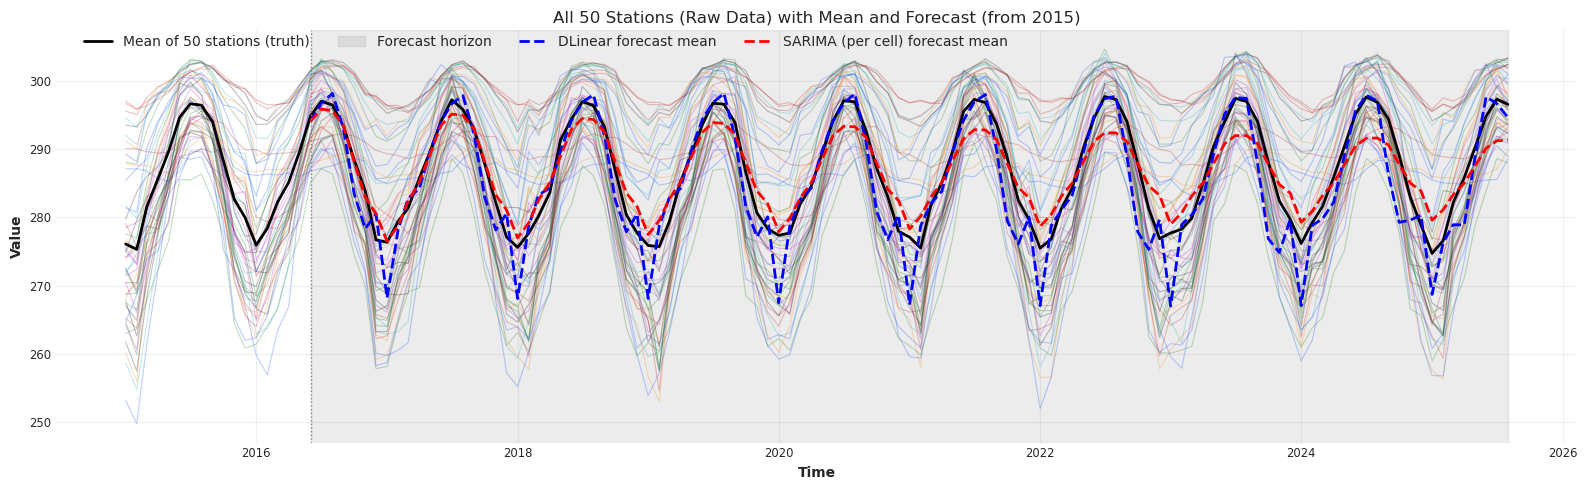

Figure saved to: photo/all_50_stations_mean_forecast_from2015.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 建立輸出資料夾
out_dir = "photo"
os.makedirs(out_dir, exist_ok=True)

# =========================
# 1. 取 raw data (T, C)
# =========================
vals = ts_all.values(copy=False)
vals = np.asarray(vals)
if vals.ndim == 3 and vals.shape[-1] == 1:
    vals = vals[..., 0]   # (T, C)

T, C = vals.shape
idx = ts_all.time_index
print(f"T={T}, C={C}")

# =========================
# 2. 取 DLinear / SARIMA 預測 (T_val, C)
# =========================
# DLinear 預測
pred_vals_dl = pred_dlinear.values(copy=False)
pred_vals_dl = np.asarray(pred_vals_dl)
if pred_vals_dl.ndim == 3 and pred_vals_dl.shape[-1] == 1:
    pred_vals_dl = pred_vals_dl[..., 0]   # (T_val, C)

# SARIMA 預測（per cell）
pred_vals_sar = pred_sarima_vals          # (T_val, C)

val_idx = val_ts.time_index
split_time = val_idx[0]

# =========================
# 3. 只畫 2015 之後
# =========================
start_plot = pd.Timestamp("2015-01-01")

# raw data 2015+
mask_2015 = idx >= start_plot
idx_2015 = idx[mask_2015]
vals_2015 = vals[mask_2015]

# 預測區間中 2015+ 的部分
mask_val_2015 = val_idx >= start_plot
val_idx_2015 = val_idx[mask_val_2015]
mean_pred_dl_2015 = pred_vals_dl[mask_val_2015].mean(axis=1)
mean_pred_sar_2015 = pred_vals_sar[mask_val_2015].mean(axis=1)

# 灰色預測區間範圍
shade_start = max(split_time, idx_2015[0])
shade_end = idx_2015[-1]

# =========================
# 4. 畫圖
# =========================
plt.figure(figsize=(16, 5))

# 1) 50 條 raw data（2015 之後，淡色）
for j in range(C):
    plt.plot(idx_2015, vals_2015[:, j], linewidth=0.8, alpha=0.25)

# 2) 真實平均（黑實線）
mean_vals_2015 = vals_2015.mean(axis=1)
plt.plot(idx_2015, mean_vals_2015,
         color="black", linewidth=2.0, label="Mean of 50 stations (truth)")

# 3) 預測區間灰底
plt.axvspan(shade_start, shade_end,
            color="grey", alpha=0.15, label="Forecast horizon")

# 4) DLinear 預測平均（藍虛線）
plt.plot(val_idx_2015, mean_pred_dl_2015,
         color="blue", linestyle="--", linewidth=2.0,
         label="DLinear forecast mean")

# 5) SARIMA 預測平均（紅虛線）
plt.plot(val_idx_2015, mean_pred_sar_2015,
         color="red", linestyle="--", linewidth=2.0,
         label="SARIMA (per cell) forecast mean")

# 6) 預測起點垂直線（如果在 2015 之後）
if split_time >= idx_2015[0]:
    plt.axvline(split_time, color="grey", linestyle=":", linewidth=1)

plt.title("All 50 Stations (Raw Data) with Mean and Forecast (from 2015)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(alpha=0.3)

# legend 放在圖外上方
plt.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 1.02),
    ncol=4,
    framealpha=0.9
)

plt.tight_layout()

# 存檔到 photo 資料夾
out_path = os.path.join(out_dir, "all_50_stations_mean_forecast_from2015.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"Figure saved to: {out_path}")
